Pipeline steps: 
0) convert to lower case, remove emojis, punctuation, special characters
1) remove stop words 
2) lemmetization (no stemming)
3) vectorize (TF-IDF) 
4) Normalize labels? I think not...what would that achieve 

In [3]:
# Imports
import sklearn
import pandas as pd
import numpy as np

# Data Exploration

In [17]:
dataframe = pd.read_csv('data_labeled.csv')
dataframe.columns = ["sentence", "label"]
print(dataframe.head())
print(dataframe.describe())


                                            sentence  label
0                                              Today      1
1  I want to print the occasion and a photo on th...      1
2  When I will get, how many days it will take to...      1
3                                           Delivery      1
4    I want gift suggestion for general in all gifts      2
            label
count  604.000000
mean     1.178808
std      0.965996
min     -2.000000
25%      1.000000
50%      1.000000
75%      2.000000
max      2.000000


Label Distribution:
label
-2     22
-1     35
 1    303
 2    244
Name: count, dtype: int64

Total samples: 604


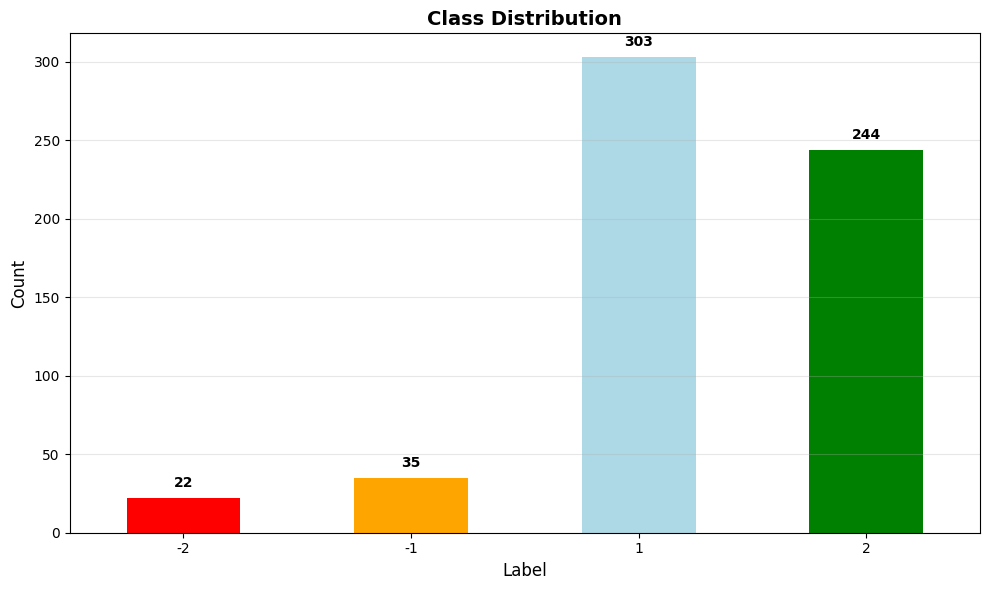


Label Meanings:
-2: Escalate to human agent
-1: Track order/order status (login required)
 1: General conversation/company policy
 2: Product recommendation


In [18]:
import matplotlib.pyplot as plt

# Count label distribution
label_counts = dataframe['label'].value_counts().sort_index()
print("Label Distribution:")
print(label_counts)
print(f"\nTotal samples: {len(dataframe)}")

# Create bar plot
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color=['red', 'orange', 'lightblue', 'green'])
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print label meanings
print("\nLabel Meanings:")
print("-2: Escalate to human agent")
print("-1: Track order/order status (login required)")
print(" 1: General conversation/company policy")
print(" 2: Product recommendation")

# Pipeline

In [19]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✓ NLTK resources downloaded")

✓ NLTK resources downloaded


In [20]:
def preprocess_text(text):
    """
    Preprocess text with the following steps:
    0) Convert to lowercase, remove emojis, punctuation, special characters
    1) Remove stop words
    2) Lemmatization
    """
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove emojis and special characters, keep only alphanumeric and spaces
    # This preserves English and other Unicode letters
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove English stop words
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 1]
    
    # Lemmatization (only works well for English words)
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)

# Test the function
sample_text = "I want gift suggestion for wife in all gifts"
print(f"Original: {sample_text}")
print(f"Processed: {preprocess_text(sample_text)}")
print()

sample_text2 = "Hello, do you deliver to pincode 560001?"
print(f"Original: {sample_text2}")
print(f"Processed: {preprocess_text(sample_text2)}")

Original: I want gift suggestion for wife in all gifts
Processed: want gift suggestion wife gift

Original: Hello, do you deliver to pincode 560001?
Processed: hello deliver pincode 560001


In [ ]:
# Apply preprocessing to all sentences
print("Preprocessing all sentences...")
dataframe['processed_sentence'] = dataframe['sentence'].apply(preprocess_text)

# Show before and after examples
print("\nBefore and After Preprocessing (first 10 rows):")
print("="*80)
for idx in range(min(10, len(dataframe))):
    print(f"\nOriginal: {dataframe['sentence'].iloc[idx]}")
    print(f"Processed: {dataframe['processed_sentence'].iloc[idx]}")
    print("-"*80)

print(f"\n✓ Preprocessing complete! Total samples: {len(dataframe)}")

## TF-IDF Vectorization

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,          # Limit to top 5000 features
    min_df=2,                   # Word must appear in at least 2 documents
    max_df=0.8,                 # Word can't appear in more than 80% of documents
    ngram_range=(1, 2),         # Use unigrams and bigrams
    lowercase=False             # Already lowercased in preprocessing
)

# Fit and transform the processed sentences
X = tfidf_vectorizer.fit_transform(dataframe['processed_sentence'])
y = dataframe['label'].values

print(f"✓ TF-IDF Vectorization Complete!")
print(f"Shape of feature matrix: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nVocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"\nSample feature names: {tfidf_vectorizer.get_feature_names_out()[:20]}")

✓ TF-IDF Vectorization Complete!
Shape of feature matrix: (604, 347)
Number of samples: 604
Number of features: 347

Vocabulary size: 347

Sample feature names: ['able' 'able add' 'account' 'activate' 'add' 'add cart' 'address' 'agent'
 'anniversary' 'app' 'art' 'available' 'baby' 'banglore' 'beer' 'best'
 'best friend' 'birthday' 'birthday gift' 'box']


In [28]:
# Examine the most important features for each class
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Top TF-IDF weighted words by class:\n")
for label in sorted(dataframe['label'].unique()):
    # Get indices for this label
    label_indices = dataframe['label'] == label
    
    # Get mean TF-IDF scores for this class
    mean_tfidf = X[label_indices.values].mean(axis=0).A1
    
    # Get top 10 features
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    
    label_name = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
    print(f"Label {label} ({label_name[label]}): {', '.join(top_words)}")
    print()

Top TF-IDF weighted words by class:

Label -2 (Escalate to agent): contact, call, talk, number, need, agent, need talk, talk agent, need call, contact number

Label -1 (Track order): order, cancel, cancel order, track, change, want cancel, track order, order delivered, delivered, placed

Label 1 (General/Policy): delivery, order, want, get, deliver, time, need, preview, card, coupon

Label 2 (Product recommendation): gift, want, want gift, gift suggestion, suggestion, birthday, friend, suggestion friend, husband, boyfriend



In [32]:
# X is the TF-IDF feature matrix where each row corresponds to a sentence and each column to a TF-IDF feature
# We have a vocabulary of 347 features : so , 347 columns
# We have total 604 sentences, so total 604 rows

print(X.shape)

(604, 347)


# Training

In [41]:
# Show first 5 rows of X (sparse matrix representation)
print("Sparse matrix representation (first 5 rows):")
print(X[:5])
print("\n" + "="*80 + "\n")

# Show as dense array to see actual values
print("Dense array representation (first 5 rows, first 20 features):")
print(X[:5, :20].toarray())
print("\nNote: Most values are 0 (sparse matrix), only non-zero TF-IDF scores are shown.")

Sparse matrix representation (first 5 rows):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24 stored elements and shape (5, 347)>
  Coords	Values
  (0, 305)	1.0
  (1, 319)	0.17095231152684595
  (1, 254)	0.5395896018923987
  (1, 239)	0.38628793381492066
  (1, 64)	0.514975728021346
  (1, 232)	0.514975728021346
  (2, 116)	0.24471491787944857
  (2, 193)	0.3227640547607368
  (2, 78)	0.22372918863684613
  (2, 295)	0.3034644809843365
  (2, 257)	0.382206242685693
  (2, 183)	0.382206242685693
  (2, 13)	0.382206242685693
  (2, 194)	0.3308565928960906
  (2, 80)	0.382206242685693
  (3, 86)	1.0
  (4, 319)	0.18455213063304396
  (4, 121)	0.3967542259606633
  (4, 282)	0.24412788031512372
  (4, 114)	0.44707631513788904
  (4, 323)	0.21814988617088898
  (4, 129)	0.24412788031512372
  (4, 288)	0.44707631513788904
  (4, 115)	0.4919206393473748


Dense array representation (first 5 rows, first 20 features):
[[0.         0.         0.         0.         0.         0.
  0.         0.         0

In [42]:
from sklearn.model_selection import train_test_split

# Split data with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 80-20 split
    random_state=42,         # For reproducibility
    stratify=y               # Maintain class distribution
)

print("✓ Train-Test Split Complete!")
print(f"\nTotal samples: {X.shape[0]}")
print(f"Training samples: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Testing samples: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

# Check class distribution in train and test sets
print("\n" + "="*80)
print("\nClass Distribution in Training Set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for label in train_dist.index:
    label_name = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
    print(f"Label {label:2d} ({label_name[label]:25s}): {train_dist[label]:3d} samples ({train_dist[label]/len(y_train)*100:5.1f}%)")

print("\nClass Distribution in Testing Set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for label in test_dist.index:
    label_name = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
    print(f"Label {label:2d} ({label_name[label]:25s}): {test_dist[label]:3d} samples ({test_dist[label]/len(y_test)*100:5.1f}%)")

✓ Train-Test Split Complete!

Total samples: 604
Training samples: 483 (80.0%)
Testing samples: 121 (20.0%)
Number of features: 347


Class Distribution in Training Set:
Label -2 (Escalate to agent        ):  18 samples (  3.7%)
Label -1 (Track order              ):  28 samples (  5.8%)
Label  1 (General/Policy           ): 242 samples ( 50.1%)
Label  2 (Product recommendation   ): 195 samples ( 40.4%)

Class Distribution in Testing Set:
Label -2 (Escalate to agent        ):   4 samples (  3.3%)
Label -1 (Track order              ):   7 samples (  5.8%)
Label  1 (General/Policy           ):  61 samples ( 50.4%)
Label  2 (Product recommendation   ):  49 samples ( 40.5%)


In [45]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

# XGBoost requires labels to be 0, 1, 2, 3... so we need to encode them
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Label mapping:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    label_name = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
    print(f"  {original} ({label_name[original]:25s}) -> {encoded}")

# Calculate class weights to handle imbalance
classes = np.unique(y_train_encoded)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_encoded)
sample_weights = np.array([class_weights[np.where(classes == label)[0][0]] for label in y_train_encoded])

print("\nClass weights:", dict(zip(label_encoder.classes_, class_weights)))
print("\n" + "="*80)

# Initialize XGBoost classifier
xgb_model = XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=4,                # 4 classes (0, 1, 2, 3)
    max_depth=6,                # Maximum depth of trees
    learning_rate=0.1,          # Learning rate
    n_estimators=100,           # Number of boosting rounds
    random_state=42,
    eval_metric='mlogloss'      # Multi-class log loss
)

print("\n✓ Training XGBoost model...")
# Train with sample weights to handle class imbalance
xgb_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)
print("✓ Training complete!")

Label mapping:
  -2 (Escalate to agent        ) -> 0
  -1 (Track order              ) -> 1
  1 (General/Policy           ) -> 2
  2 (Product recommendation   ) -> 3

Class weights: {np.int64(-2): np.float64(6.708333333333333), np.int64(-1): np.float64(4.3125), np.int64(1): np.float64(0.4989669421487603), np.int64(2): np.float64(0.6192307692307693)}


✓ Training XGBoost model...
✓ Training complete!


In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Make predictions on training and test sets (encoded labels)
y_train_pred_encoded = xgb_model.predict(X_train)
y_test_pred_encoded = xgb_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_encoded, y_train_pred_encoded)
test_accuracy = accuracy_score(y_test_encoded, y_test_pred_encoded)

# Calculate F1 scores
train_f1_macro = f1_score(y_train_encoded, y_train_pred_encoded, average='macro')
test_f1_macro = f1_score(y_test_encoded, y_test_pred_encoded, average='macro')
train_f1_weighted = f1_score(y_train_encoded, y_train_pred_encoded, average='weighted')
test_f1_weighted = f1_score(y_test_encoded, y_test_pred_encoded, average='weighted')

print("="*80)
print("MODEL PERFORMANCE")
print("="*80)
print(f"\nTraining Set:")
print(f"  Accuracy:        {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  F1-Score (Macro):    {train_f1_macro:.4f}")
print(f"  F1-Score (Weighted): {train_f1_weighted:.4f}")

print(f"\nValidation/Test Set:")
print(f"  Accuracy:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  F1-Score (Macro):    {test_f1_macro:.4f}")
print(f"  F1-Score (Weighted): {test_f1_weighted:.4f}")

print("\n" + "="*80)
print("\nDetailed Classification Report (Test Set):")
print("="*80)
# Use original labels for reporting
y_test_pred_original = label_encoder.inverse_transform(y_test_pred_encoded)
label_names = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
target_names = [label_names[label] for label in sorted(np.unique(y_test))]
print(classification_report(y_test, y_test_pred_original, target_names=target_names))

MODEL PERFORMANCE

Training Set:
  Accuracy:        0.9110 (91.10%)
  F1-Score (Macro):    0.9080
  F1-Score (Weighted): 0.9119

Validation/Test Set:
  Accuracy:        0.8099 (80.99%)
  F1-Score (Macro):    0.7636
  F1-Score (Weighted): 0.8093


Detailed Classification Report (Test Set):
                        precision    recall  f1-score   support

     Escalate to agent       1.00      0.50      0.67         4
           Track order       0.67      0.86      0.75         7
        General/Policy       0.81      0.82      0.81        61
Product recommendation       0.83      0.82      0.82        49

              accuracy                           0.81       121
             macro avg       0.83      0.75      0.76       121
          weighted avg       0.82      0.81      0.81       121



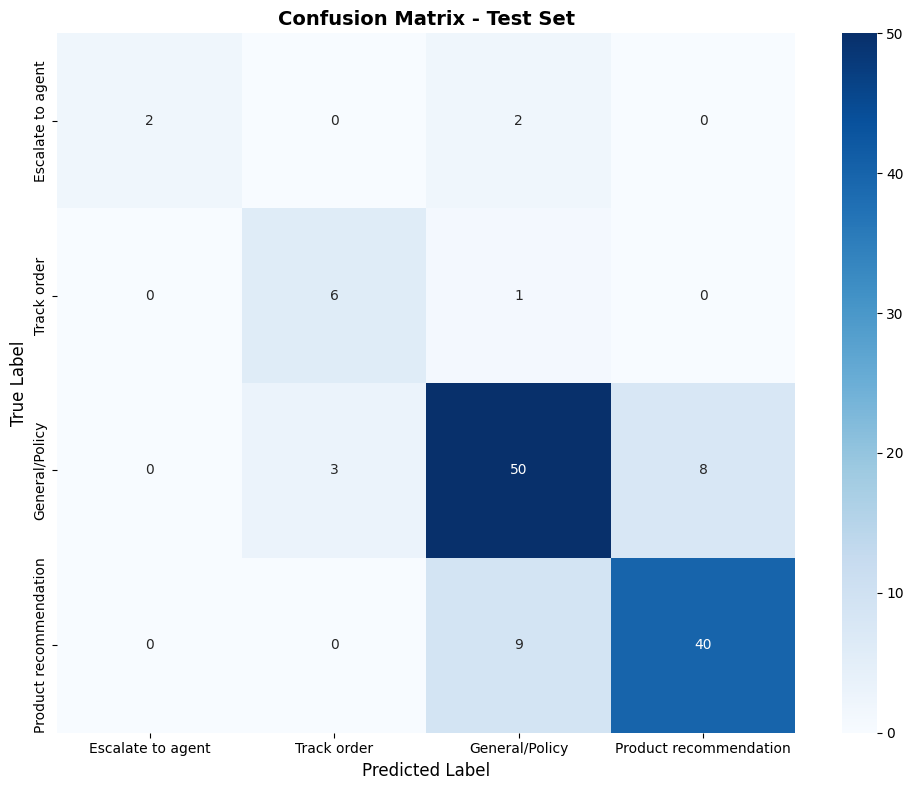


Sample Misclassified Examples:

1. Original: I want to print the occasion and a photo on the cover page
   True Label: -2 (Escalate to agent)
   Predicted: 1 (General/Policy)

2. Original: I want gift suggestion for wife in all gifts
   True Label: 1 (General/Policy)
   Predicted: 2 (Product recommendation)

3. Original: I have selected a gold coin photo engraved can u add and give me a ring to it to wear it as a dollar
   True Label: 1 (General/Policy)
   Predicted: 2 (Product recommendation)

4. Original: I want a customised scroll can you do it in hindi
   True Label: -2 (Escalate to agent)
   Predicted: 1 (General/Policy)

5. Original: in how much time u ll deliver
   True Label: 2 (Product recommendation)
   Predicted: 1 (General/Policy)


In [49]:
# Confusion Matrix visualization
import seaborn as sns

# Use original labels for confusion matrix
y_test_pred_original = label_encoder.inverse_transform(y_test_pred_encoded)
cm = confusion_matrix(y_test, y_test_pred_original)
labels = sorted(np.unique(y_test))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[label_names[l] for l in labels],
            yticklabels=[label_names[l] for l in labels])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show some misclassified examples
print("\n" + "="*80)
print("Sample Misclassified Examples:")
print("="*80)
misclassified_indices = np.where(y_test != y_test_pred_original)[0]

if len(misclassified_indices) > 0:
    # Get original indices from test set
    test_indices = np.arange(len(dataframe))[np.isin(np.arange(len(dataframe)), 
                                                      dataframe.index[dataframe['label'].isin(y_test)])]
    
    for i, idx in enumerate(misclassified_indices[:5]):  # Show first 5
        print(f"\n{i+1}. Original: {dataframe.iloc[idx]['sentence']}")
        print(f"   True Label: {y_test[idx]} ({label_names[y_test[idx]]})")
        print(f"   Predicted: {y_test_pred_original[idx]} ({label_names[y_test_pred_original[idx]]})")
else:
    print("\n✓ Perfect predictions! No misclassified examples.")